# Distorted Visual Sequence Pattern Recognition using Deep Learning
### CIG Open Projects 2026 - AI/ML Track Submission

**Author:** Aryan Mehra  
**Enrollment:** 23115025  

---

## What we are doing here:
1. **Setup & Data**: Mounting drive and getting libraries
2. **EDA**: Cleaning the messy labels
3. **Preprocessing**: Dataset class and transforms
4. **Model Architecture**: Our custom CNN+LSTM model
5. **Training**: Training loop and CER calculation
6. **Evaluation**: Checking how well it learned
7. **Submission**: Running on test data and saving CSV

## 1. Setup & Imports
importing all the standard stuff we need.

In [1]:
import os
import sys
import re
import shutil
import subprocess

# Must be set BEFORE torch is imported. On Apple silicon this routes any
# op that MPS has not implemented to the CPU instead of raising.
os.environ.setdefault('PYTORCH_ENABLE_MPS_FALLBACK', '1')
import json
import time
import math
import random
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
from PIL import Image
import cv2
# OpenCV spawns its own thread pool; with DataLoader workers that fights
# for cores and slows things down. One line, big difference on Colab.
cv2.setNumThreads(0)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

# setting seeds so we get same results every time
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

def pick_device():
    """Probe each backend for real instead of trusting is_available()."""
    if torch.cuda.is_available():
        try:
            torch.zeros(1).to('cuda')
            return 'cuda'
        except Exception as e:
            print(f'CUDA present but unusable ({e}) -> trying next backend')

    if getattr(torch.backends, 'mps', None) is not None and torch.backends.mps.is_available():
        # Apple GPU. Several torch builds ship MPS without a CTC kernel, and
        # CTC is the one op this whole notebook depends on, so test it directly.
        try:
            lp = torch.randn(20, 1, 6, device='mps').log_softmax(2)
            nn.CTCLoss(blank=0, zero_infinity=True)(
                lp,
                torch.tensor([1, 2, 3], device='mps'),
                torch.full((1,), 20, dtype=torch.long, device='mps'),
                torch.full((1,), 3, dtype=torch.long, device='mps'))
            return 'mps'
        except Exception as e:
            print(f'MPS present but CTC unsupported ({type(e).__name__}) -> using CPU')

    return 'cpu'


dev = pick_device()
print(f'Device: {dev}')
# Input size is fixed at 48x160, so let cuDNN pick the fastest kernels once
# and reuse them. Free speedup; only pays off with a static input shape.
if dev == 'cuda':
    torch.backends.cudnn.benchmark = True
if dev == 'cpu':
    print('NOTE: no GPU found. Full training (80 epochs) will take many hours here.\n'
          '      Set quick_run=True to smoke-test the pipeline, or run on Colab (T4).')

# editdistance is needed everywhere, not just on Colab/Kaggle
try:
    import editdistance
except ImportError:
    print('installing editdistance ...')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'editdistance'], check=True)
    import editdistance
print('editdistance ready.')

Device: cuda
editdistance ready.


## Data Download

In [2]:
# ── Locate the dataset ───────────────────────────────────────────────────────
# Finds the folder holding train-labels.csv on whichever machine this runs on:
# Colab (downloads + extracts), Kaggle, Google Drive, or a local copy under any
# name ("cig_ps", "cig_ps 2", a Downloads copy...). If detection ever fails the
# cell prints what it actually saw, and you can hard-set the path below.

DATA_DIR_OVERRIDE = None      # e.g. '/content/cig_ps'  or  '/Users/aryan/Desktop/cig_ps 2'

import os
import sys
import zipfile
import subprocess
from pathlib import Path

colab  = 'google.colab' in sys.modules
kaggle = 'kaggle_secrets' in sys.modules or '/kaggle' in sys.prefix or os.path.exists('/kaggle')

IMG_EXTS = ('.png', '.jpg', '.jpeg', '.bmp', '.tif', '.tiff')

# ---- where checkpoints and the submission get written -----------------------
if colab:
    from google.colab import drive
    drive.mount('/content/drive')
    root = Path('/content/drive/MyDrive/CIG_Pattern_Recognition')
elif kaggle:
    root = Path('/kaggle/working')
else:
    root = Path.cwd()
root.mkdir(parents=True, exist_ok=True)
print(f'Output dir : {root}')


def is_complete(d):
    """A usable dataset dir has the csv and both image folders."""
    d = Path(d)
    return ((d / 'train-labels.csv').is_file()
            and (d / 'train_images').is_dir()
            and (d / 'test_images').is_dir())


# ---- download + extract, Colab only -----------------------------------------
if colab:
    zip_path = Path('/content/cig_ps.zip')

    if not zip_path.exists():
        print('Downloading dataset ...')
        subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'gdown'], check=False)
        subprocess.run(
            ['gdown', '--fuzzy',
             'https://drive.google.com/uc?id=1e0Bpbmjp-Pc1Oz7luC1g8JhfzKpGZRHu',
             '-O', str(zip_path)],
            check=True)

    if zip_path.exists():
        # gdown exits 0 even when Drive hands back an HTML quota/permission page,
        # so check the bytes are actually a zip rather than trusting the exit code.
        assert zipfile.is_zipfile(zip_path), (
            f'{zip_path} is {zip_path.stat().st_size} bytes but is not a zip. '
            'Drive most likely returned a quota or permission page instead of the '
            'file. Run  !rm /content/cig_ps.zip  and retry, or copy the dataset '
            'into your Drive and set DATA_DIR_OVERRIDE.')

        # NOTE: glob('cig_ps*') would also match cig_ps.zip itself, which is how
        # an earlier version silently skipped extraction. Test for a *complete
        # dataset directory* instead of a name pattern, so it works whether the
        # zip has a top-level cig_ps/ folder or unpacks straight into /content.
        _c = Path('/content')
        extracted = [p for p in [_c] + [q for q in _c.iterdir() if q.is_dir()]
                     if is_complete(p)]
        if extracted:
            print(f'Already extracted: {extracted[0]}')
        else:
            print('Extracting to local Colab disk ...')
            with zipfile.ZipFile(zip_path) as z:
                z.extractall('/content/')
            print('Extraction done.')

# ---- search for a complete dataset dir --------------------------------------
SKIP = {'node_modules', '__pycache__', 'Library', 'Applications',
        'site-packages', 'dist-packages', '.git', 'venv', '.venv',
        'sample_data', '.shortcut-targets-by-id'}

# (root, max_depth). Drive is a FUSE mount and walking it deeply is slow,
# so it gets a shallow budget plus one targeted deeper look.
SEARCH_ROOTS = [
    (Path('/content'), 4),
    (Path('/kaggle/input'), 4),
    (Path.cwd(), 4),
    (Path.cwd().parent, 3),
    (Path('/content/drive/MyDrive'), 2),
    (Path('/content/drive/MyDrive/CIG_Pattern_Recognition'), 3),
    (Path.home() / 'Downloads', 4),
    (Path.home() / 'Desktop', 4),
    (Path.home() / 'Documents', 4),
]


def find_dataset_dirs():
    """Every directory containing train-labels.csv, nearest roots first."""
    found, seen_roots = [], set()
    for r, max_depth in SEARCH_ROOTS:
        if not r.is_dir():
            continue
        key = str(r.resolve())
        if key in seen_roots:
            continue
        seen_roots.add(key)

        base = len(r.resolve().parts)
        for dirpath, dirnames, filenames in os.walk(r, followlinks=False):
            d = Path(dirpath)
            if len(d.resolve().parts) - base >= max_depth:
                dirnames[:] = []
            dirnames[:] = [x for x in dirnames if not x.startswith('.') and x not in SKIP]
            if 'train-labels.csv' in filenames and d not in found:
                found.append(d)
    return found


if DATA_DIR_OVERRIDE:
    DATA_DIR = Path(DATA_DIR_OVERRIDE).expanduser()
    assert is_complete(DATA_DIR), (
        f'DATA_DIR_OVERRIDE={DATA_DIR} must contain train-labels.csv, '
        'train_images/ and test_images/')
else:
    cands = find_dataset_dirs()
    if cands:
        print('\nFound dataset candidate(s):')
        for c in cands:
            print(f'  {"OK     " if is_complete(c) else "partial"}  {c}')
    good = [c for c in cands if is_complete(c)]

    if not good:
        # Say what was actually on disk instead of just failing.
        print('\n--- diagnostics ---')
        for p in [Path('/content'), Path('/content/drive/MyDrive'), Path.cwd()]:
            if p.is_dir():
                names = sorted(x.name + ('/' if x.is_dir() else '') for x in p.iterdir())
                print(f'{p} -> {names[:25]}')
        zp = Path('/content/cig_ps.zip')
        if zp.exists():
            print(f'{zp} -> {zp.stat().st_size:,} bytes, '
                  f'valid zip: {zipfile.is_zipfile(zp)}')

    assert good, (
        'No folder found containing train-labels.csv + train_images/ + test_images/.\n'
        'See the diagnostics above, then set DATA_DIR_OVERRIDE at the top of this '
        'cell to the right path and re-run.')
    DATA_DIR = good[0]

tr_dir  = DATA_DIR / 'train_images'
te_dir  = DATA_DIR / 'test_images'
lbl_csv = DATA_DIR / 'train-labels.csv'

n_train = sum(1 for f in os.listdir(tr_dir) if f.lower().endswith(IMG_EXTS))
n_test  = sum(1 for f in os.listdir(te_dir) if f.lower().endswith(IMG_EXTS))
assert n_train > 0, f'no images in {tr_dir}'
assert n_test  > 0, f'no images in {te_dir}'

print(f'\nDATA_DIR   : {DATA_DIR}')
print(f'train imgs : {n_train}')
print(f'test imgs  : {n_test}')
print('Environment configured successfully!')


Mounted at /content/drive
Output dir : /content/drive/MyDrive/CIG_Pattern_Recognition
Extracting to local Colab disk ...
Extraction done.

Found dataset candidate(s):
  OK       /content/cig_ps

DATA_DIR   : /content/cig_ps
train imgs : 20000
test imgs  : 5000
Environment configured successfully!


## 2. Cleaning Data (EDA)
Some rows in the csv are corrupted (like dates/scientific notation). filtering out anything that doesn't have length 6.


In [3]:
# dtype=str is load-bearing: without it pandas reinterprets labels, so
# '007123' becomes 7123 and '1E2345' becomes inf. Those then fail the
# length-6 filter below and you silently throw away valid training rows.
raw = pd.read_csv(lbl_csv, dtype=str, keep_default_na=False)
assert {'image', 'text'}.issubset(raw.columns), f'unexpected columns: {list(raw.columns)}'
print(f"Raw dataset length: {len(raw)} rows")

# removing rows where excel messed up the text length
raw['len'] = raw['text'].astype(str).apply(len)
anomalous = raw[raw['len'] != 6]
print(f"Found {len(anomalous)} anomalous samples:")
print(anomalous)

# remove bad rows
clean = raw[raw['len'] == 6].drop(columns=['len']).reset_index(drop=True)
print(f"Clean dataset length: {len(clean)} rows")
assert len(clean) > 0, 'every row was filtered out - check the length-6 assumption'

# making vocabulary from all unique characters
vocab_chars = sorted(list(set(''.join(clean['text'].tolist()))))
vocab = ['<blank>'] + vocab_chars
nch = len(vocab)

c2i = {c: i for i, c in enumerate(vocab)}
i2c = {i: c for c, i in c2i.items()}

print(f"Vocab size (including blank): {nch}")
print(f"Vocabulary: {vocab}")
assert nch > 1, 'empty vocabulary'

Raw dataset length: 20000 rows
Found 2 anomalous samples:
     Unnamed: 0           image       text  len
2184       2184  train-2184.png   5.40E+12    8
6819       6819  train-6819.png  04-Mar-54    9
Clean dataset length: 19998 rows
Vocab size (including blank): 32
Vocabulary: ['<blank>', '2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


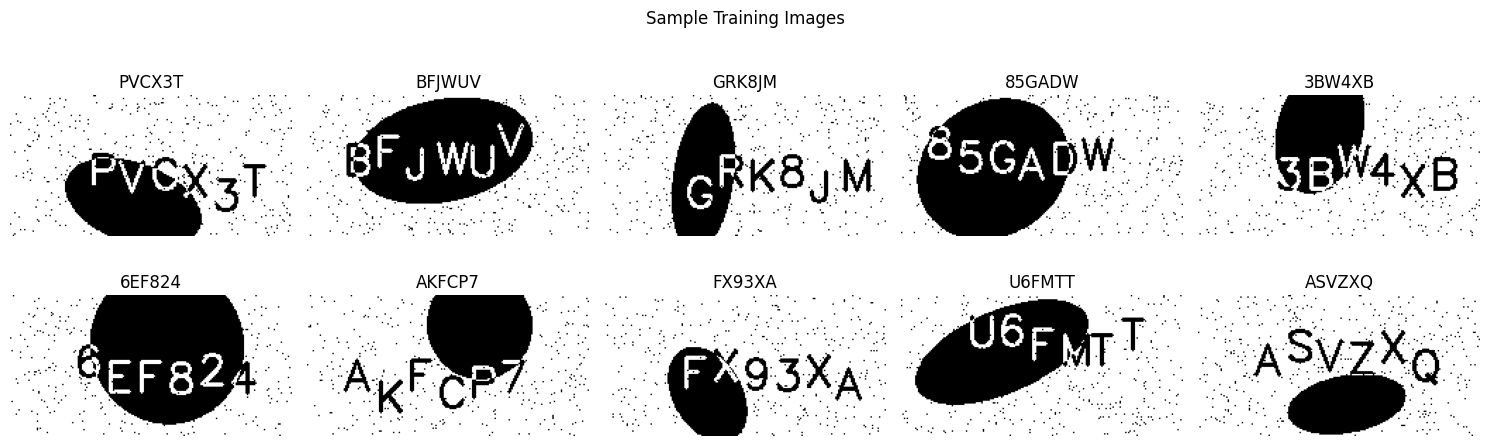

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(15, 5))
samples = raw.sample(10, random_state=1).reset_index(drop=True)
for i, ax in enumerate(axes.flat):
    img = cv2.imread(str(tr_dir / samples.loc[i, 'image']), cv2.IMREAD_GRAYSCALE)
    ax.imshow(img, cmap='gray')
    ax.set_title(samples.loc[i, 'text'])
    ax.axis('off')
plt.suptitle('Sample Training Images')
plt.tight_layout()
plt.show()


## 2b. OpenCV Preprocessing
Denoise + local contrast normalisation before the tensor pipeline. Deliberately *not* binarising by default (see the docstring).


In [5]:
# ── OpenCV front-end ──────────────────────────────────────────────────────────
# Written as a PIL -> PIL callable so it drops straight into torchvision's
# Compose. The Dataset classes in the next cell need zero changes.

class CVPreprocess:
    """
    OpenCV preprocessing for the CRNN.

    grayscale -> medianBlur (speckle / salt-pepper)
              -> CLAHE      (local contrast, fixes uneven backgrounds)
              -> morph open (optional: thin strike-through lines)
              -> Otsu       (optional, OFF by default)

    Why binarize=False by default: Otsu discards the anti-aliased grey pixels
    at stroke edges, and those are exactly what the CNN leans on when a
    character is low-contrast against the background. Binarising a CRNN's
    input usually costs CER. Flip it on only to generate the ablation number
    for the writeup.

    Why morph_open=0 by default: opening removes small *bright* structures.
    That helps only if the noise is brighter than the glyphs. Check the
    polarity in the plot below before enabling it, else it eats strokes.
    """

    def __init__(self, median=3, clahe_clip=2.0, clahe_grid=(8, 8),
                 morph_open=0, binarize=False):
        self.median     = median
        self.clahe_clip = clahe_clip
        self.clahe_grid = clahe_grid
        self.morph_open = morph_open
        self.binarize   = binarize
        self._clahe     = None   # built lazily -> picklable across DataLoader workers

    def _clahe_op(self):
        if self._clahe is None:
            self._clahe = cv2.createCLAHE(clipLimit=self.clahe_clip,
                                          tileGridSize=self.clahe_grid)
        return self._clahe

    def __getstate__(self):
        # The cached cv2.CLAHE handle cannot be pickled. Drop it so this
        # transform still survives DataLoader workers started with 'spawn'
        # (Windows / notebooks that set it explicitly). Under fork it is
        # inherited anyway, so nothing is lost either way.
        st = self.__dict__.copy()
        st['_clahe'] = None
        return st

    def stages(self, pil_img):
        """Runs the pipeline and returns every intermediate, for plotting.
        __call__ uses this too, so what you see below is exactly what the
        model gets fed."""
        out = {}
        a = np.array(pil_img.convert('L'))
        out['1 grayscale'] = a

        if self.median and self.median > 1:
            a = cv2.medianBlur(a, self.median)
            out[f'2 medianBlur {self.median}'] = a

        if self.clahe_clip and self.clahe_clip > 0:
            a = self._clahe_op().apply(a)
            out[f'3 CLAHE clip={self.clahe_clip}'] = a

        if self.morph_open and self.morph_open > 0:
            k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,
                                          (self.morph_open, self.morph_open))
            a = cv2.morphologyEx(a, cv2.MORPH_OPEN, k)
            out[f'4 morph open {self.morph_open}'] = a

        if self.binarize:
            _, a = cv2.threshold(a, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
            out['5 Otsu'] = a

        return out

    def __call__(self, pil_img):
        return Image.fromarray(next(reversed(self.stages(pil_img).values())))


# one shared instance -> train / val / test cannot drift apart
cvp = CVPreprocess(median=3, clahe_clip=2.0, morph_open=0, binarize=False)
print('OpenCV stage:', list(cvp.stages(Image.open(tr_dir / clean.loc[0, "image"])).keys()))


OpenCV stage: ['1 grayscale', '2 medianBlur 3', '3 CLAHE clip=2.0']


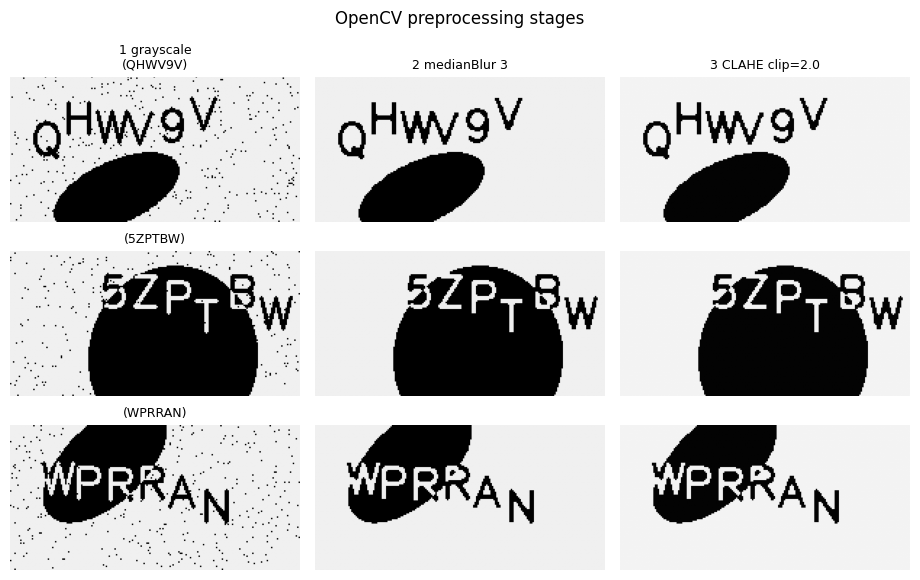

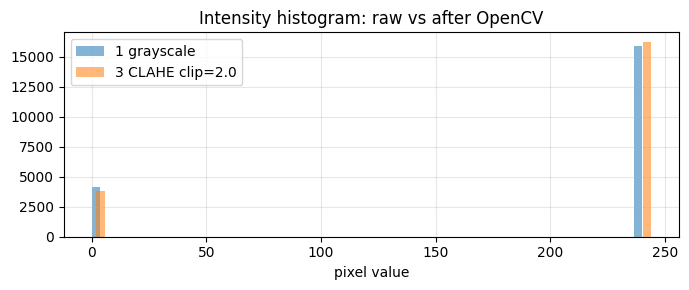

In [6]:
# every OpenCV stage, side by side, on a few random training images
demo = clean.sample(3, random_state=7).reset_index(drop=True)
names = list(cvp.stages(Image.open(tr_dir / demo.loc[0, 'image'])).keys())

fig, axes = plt.subplots(len(demo), len(names),
                         figsize=(3.1 * len(names), 2.0 * len(demo)))
axes = np.atleast_2d(axes)
for r in range(len(demo)):
    st = cvp.stages(Image.open(tr_dir / demo.loc[r, 'image']))
    for c, name in enumerate(names):
        axes[r, c].imshow(st[name], cmap='gray', vmin=0, vmax=255)
        axes[r, c].axis('off')
        axes[r, c].set_title(name if r == 0 else '', fontsize=9)
    axes[r, 0].set_title(f"{names[0]}\n({demo.loc[r,'text']})" if r == 0
                         else f"({demo.loc[r,'text']})", fontsize=9)
plt.suptitle('OpenCV preprocessing stages')
plt.tight_layout()
plt.show()

# did CLAHE actually spread the intensities out, or is it a no-op here?
st = cvp.stages(Image.open(tr_dir / clean.loc[0, 'image']))
fig, ax = plt.subplots(figsize=(7, 3))
for name in (names[0], names[-1]):
    ax.hist(st[name].ravel(), bins=64, alpha=0.55, label=name)
ax.set_title('Intensity histogram: raw vs after OpenCV')
ax.set_xlabel('pixel value'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Dataset & Dataloaders
Creating custom Dataset. Used some basic augmentations like ColorJitter and Gaussian Noise so model doesn't overfit.


In [7]:
from sklearn.model_selection import train_test_split

trdf, vdf = train_test_split(clean, test_size=0.10, random_state=42, shuffle=True)
trdf = trdf.reset_index(drop=True)
vdf   = vdf.reset_index(drop=True)

class GNoise:
    def __init__(self, std=0.06, p=0.40):
        self.std = std
        self.p   = p
    def __call__(self, tensor):
        if random.random() < self.p:
            noise = torch.randn_like(tensor) * self.std
            return torch.clamp(tensor + noise, -1.0, 1.0)
        return tensor

class ImgDS(Dataset):
    def __init__(self, df, img_dir, c2i, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.c2i = c2i
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row['image'])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = torch.tensor([self.c2i[c] for c in row['text']], dtype=torch.long)
        return image, label, row['text']

class TestDS(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        # The old version assumed every filename looked like 'test-123.png'
        # and crashed on anything else. Sort on the last number in the name,
        # falling back to plain alphabetical when there isn't one.
        files = [f for f in os.listdir(img_dir) if f.lower().endswith(IMG_EXTS)]
        assert files, f'no images found in {img_dir}'

        def numkey(name):
            nums = re.findall(r'\d+', name)
            return (0, int(nums[-1]), name) if nums else (1, 0, name)

        self.filenames = sorted(files, key=numkey)
    def __len__(self):
        return len(self.filenames)
    def __getitem__(self, idx):
        fname = self.filenames[idx]
        image = Image.open(os.path.join(self.img_dir, fname)).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, fname

def collate_fn(batch):
    images, labels, texts = zip(*batch)
    images = torch.stack(images)
    lens = torch.tensor([len(l) for l in labels], dtype=torch.long)
    tgt = torch.cat(labels)
    return images, tgt, lens, list(texts)

# simple augmentations
aug = T.Compose([
    cvp,                       # <-- OpenCV stage
    T.Grayscale(num_output_channels=1),
    T.Resize((48, 160)),
    T.ColorJitter(brightness=0.35, contrast=0.35),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
    GNoise(std=0.06, p=0.4),
    T.RandomErasing(p=0.45, scale=(0.03, 0.15), value=-1.0)
])

vaug = T.Compose([
    cvp,                       # <-- same OpenCV stage, no augmentation
    T.Grayscale(num_output_channels=1),
    T.Resize((48, 160)),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5])
])

# dataloaders
# Local macOS/Windows notebooks use the 'spawn' start method, where extra
# workers often hang or re-import the notebook. 0 is the safe default there.
# persistent_workers is off on purpose: keeping workers alive across epochs
# saves very little at this scale, but if you interrupt the training cell the
# stale loader raises 'DataLoader worker exited unexpectedly' on every later
# cell until you rebuild it. Not worth the recovery hassle.
nw = 2 if (colab or kaggle) else 0
pin = (dev == 'cuda')
tr_ds = ImgDS(trdf, tr_dir, c2i, transform=aug)
v_ds   = ImgDS(vdf, tr_dir, c2i, transform=vaug)

dl = DataLoader(tr_ds, batch_size=64, shuffle=True, collate_fn=collate_fn, num_workers=nw, pin_memory=pin, persistent_workers=False)
vdl   = DataLoader(v_ds, batch_size=64, shuffle=False, collate_fn=collate_fn, num_workers=nw, pin_memory=pin, persistent_workers=False)

print(f"Train batches: {len(dl)} | Val batches: {len(vdl)}")

Train batches: 282 | Val batches: 32


## 4. Custom Model Architecture
Built a custom CRNN using Conv blocks and a Bidirectional LSTM.
Used AdaptiveAvgPool to fix the height to 1.

Our model uses a CNN feature extractor backbone, collapsed sequence height, Bidirectional LSTMs, and a final fully connected classification layer projected to vocabulary classes.

In [8]:
class OCRNet(nn.Module):
    def __init__(self, nch: int, h_dim: int = 256, n_layers: int = 2, dropout: float = 0.25):
        super().__init__()

        def conv_block(in_ch, out_ch, pool=None):
            layers = [
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
                nn.BatchNorm2d(out_ch),
                nn.ReLU(inplace=True)
            ]
            if pool is not None:
                layers.append(nn.MaxPool2d(pool))   # kernel == stride
            return nn.Sequential(*layers)

        # Later pools are (2,1): they halve height but keep width, so the CTC
        # sequence stays 40 frames long instead of collapsing to 10. Six
        # characters over 10 frames is under two frames per character, which
        # is far too tight for CTC to localise cleanly.
        # To revert: change both (2, 1) back to (2, 2).
        self.cnn = nn.Sequential(
            conv_block(  1,  64, pool=(2, 2)),  # ->  64x24x80
            conv_block( 64, 128, pool=(2, 2)),  # -> 128x12x40
            conv_block(128, 256, pool=None),    # -> 256x12x40
            conv_block(256, 256, pool=(2, 1)),  # -> 256x 6x40
            conv_block(256, 512, pool=None),    # -> 512x 6x40
            conv_block(512, 512, pool=(2, 1)),  # -> 512x 3x40
            conv_block(512, 512, pool=None),    # -> 512x 3x40
        )
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, None))

        self.lstm = nn.LSTM(
            input_size=512, hidden_size=h_dim, num_layers=n_layers,
            batch_first=False, bidirectional=True, dropout=dropout if n_layers > 1 else 0.0
        )

        self.fc = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(h_dim * 2, nch)
        )

    def forward(self, x):
        features = self.cnn(x)                      # (B, 512, H_out, W_out)
        features = self.adaptive_pool(features)     # (B, 512, 1, W_out)
        features = features.squeeze(2)              # (B, 512, W_out)
        features = features.permute(2, 0, 1)        # (T, B, 512)

        lstm_out, _ = self.lstm(features)           # (T, B, 512)
        logits = self.fc(lstm_out)                  # (T, B, nch)
        return F.log_softmax(logits, dim=2)

net = OCRNet(nch=nch).to(dev) # instantiate model
print(f"Model parameters: {sum(p.numel() for p in net.parameters() if p.requires_grad):,}")

# sanity check: CTC needs T >= label_len + (number of adjacent repeats)
with torch.no_grad():
    T_out = net(torch.zeros(1, 1, 48, 160, device=dev)).shape[0]
print(f"CTC timesteps T = {T_out} for label length 6")
assert T_out >= 13, 'T too small: a label with repeated characters cannot be represented'

Model parameters: 10,032,096
CTC timesteps T = 40 for label length 6


## 5. Training Strategy
Using AdamW optimizer and CosineAnnealingLR for learning rate. Tracking the Validation CER (Character Error Rate) to save the best model.


In [9]:
quick_run = False

if quick_run:
    max_ep   = 3
    wait_lim = 3
    print("Running in quick_run mode.")
else:
    # Shortened from 80. Your CER was already ~0.022 by epoch 21 on the long
    # schedule, and the cosine LR is tied to max_ep below, so it now anneals
    # to its floor by the end of this run instead of being cut off mid-decay.
    # Want longer? Change max_ep here only - T_max follows automatically.
    max_ep   = 35
    wait_lim = 8
    print("Running in FULL training mode.")

print(f"max_ep = {max_ep}, early-stop patience = {wait_lim}")

ctc = nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)
opt = AdamW(net.parameters(), lr=1e-3, weight_decay=1e-4)
sched = CosineAnnealingLR(opt, T_max=max_ep, eta_min=1e-5)
# Mixed precision only helps on CUDA; elsewhere the scaler is a no-op.
amp_dev = 'cuda' if dev == 'cuda' else 'cpu'
fp16    = torch.amp.GradScaler(amp_dev, enabled=(dev == 'cuda'))

Running in FULL training mode.
max_ep = 35, early-stop patience = 8


In [10]:
def greedy(lp, i2c, blank_idx=0):
    preds = lp.argmax(dim=2).permute(1, 0).cpu().numpy()
    rows = []
    for seq in preds:
        chars = []
        prev = -1
        for token in seq:
            if token != prev and token != blank_idx:
                chars.append(i2c[int(token)])
            prev = token
        rows.append(''.join(chars))
    return rows

def cer_fn(predictions, ground_truths):
    import editdistance
    total = sum(editdistance.eval(p, g) / max(len(g), 1) for p, g in zip(predictions, ground_truths))
    return total / len(predictions)

def fwdbwd(net, loader, ctc, opt, fp16, device):
    net.train()
    acc = 0.0
    for imgs, tgt, lens, _ in tqdm(loader, desc="Train", leave=False):
        imgs = imgs.to(device, non_blocking=True)
        tgt = tgt.to(device)
        lens = lens.to(device)

        opt.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=('cuda' if device == 'cuda' else 'cpu'),
                                enabled=(device == 'cuda')):
            lp = net(imgs)
            T, B, _ = lp.shape
            in_len = torch.full((B,), T, dtype=torch.long, device=device)
            loss = ctc(lp, tgt, in_len, lens)

        fp16.scale(loss).backward()
        fp16.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(net.parameters(), 5.0)
        fp16.step(opt)
        fp16.update()
        acc += loss.item()
    return acc / len(loader)

def val_run(net, loader, ctc, device, i2c):
    net.eval()
    acc = 0.0
    pp, gg = [], []
    with torch.no_grad():
        for imgs, tgt, lens, texts in loader:
            imgs = imgs.to(device, non_blocking=True)
            tgt = tgt.to(device)
            lens = lens.to(device)

            lp = net(imgs)
            T, B, _ = lp.shape
            in_len = torch.full((B,), T, dtype=torch.long, device=device)
            loss = ctc(lp, tgt, in_len, lens)
            acc += loss.item()

            decoded = greedy(lp, i2c, blank_idx=0)
            pp.extend(decoded)
            gg.extend(texts)
    return acc / len(loader), cer_fn(pp, gg)

In [11]:
bst = float('inf')
strike = 0
log = {'tl': [], 'vl': [], 'bst_cer': []}
savepath = root / 'best_model.pth'

# A fresh run starts from bst=inf and will overwrite the checkpoint on its very
# first epoch, even if the previous run was better. Keep a copy first.
if savepath.exists():
    backup = root / 'best_model_prev.pth'
    shutil.copy2(savepath, backup)
    try:
        _p = torch.load(savepath, map_location='cpu')
        print(f"Previous checkpoint (epoch {_p['ep']}, CER {_p['bst_cer']:.4f}) backed up -> {backup}")
    except Exception:
        print(f"Previous checkpoint backed up -> {backup}")

for epoch in range(1, max_ep + 1):
    t0 = time.time()
    tl = fwdbwd(net, dl, ctc, opt, fp16, dev)
    vl, vc = val_run(net, vdl, ctc, dev, i2c)
    sched.step()

    log['tl'].append(tl)
    log['vl'].append(vl)
    log['bst_cer'].append(vc)

    improved = vc < bst
    if improved:
        bst = vc
        strike = 0
        torch.save({'wts': net.state_dict(), 'ep': epoch, 'bst_cer': vc}, savepath)
        status = "Saved checkpoint"
    else:
        strike += 1
        status = f"(Patience: {strike}/{wait_lim})"

    print(f"Epoch {epoch:02d} | Train Loss: {tl:.4f} | Val Loss: {vl:.4f} | Val CER: {vc:.4f} | Time: {time.time()-t0:.1f}s | {status}")

    if strike >= wait_lim:
        print("Early stopping triggered!")
        break

Previous checkpoint (epoch 25, CER 0.0130) backed up -> /content/drive/MyDrive/CIG_Pattern_Recognition/best_model_prev.pth


Train:   0%|          | 0/282 [00:00<?, ?it/s]

Epoch 01 | Train Loss: 3.9847 | Val Loss: 3.6229 | Val CER: 0.9670 | Time: 94.5s | Saved checkpoint


Train:   0%|          | 0/282 [00:00<?, ?it/s]

Epoch 02 | Train Loss: 3.6086 | Val Loss: 3.6070 | Val CER: 0.9477 | Time: 45.8s | Saved checkpoint


...

Train:   0%|          | 0/282 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78927220cea0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/python3.13/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x78927220cea0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
    if w.is_alive():
  File "/usr/lib/

Epoch 34 | Train Loss: 0.1362 | Val Loss: 0.0041 | Val CER: 0.0010 | Time: 45.5s | (Patience: 4/8)


Train:   0%|          | 0/282 [00:00<?, ?it/s]

Epoch 35 | Train Loss: 0.1326 | Val Loss: 0.0039 | Val CER: 0.0010 | Time: 43.4s | (Patience: 5/8)


## 6. Evaluation
Let's plot the loss curves and see the best CER achieved.

Visualizing the loss decay profiles and matching performance trends over epochs.

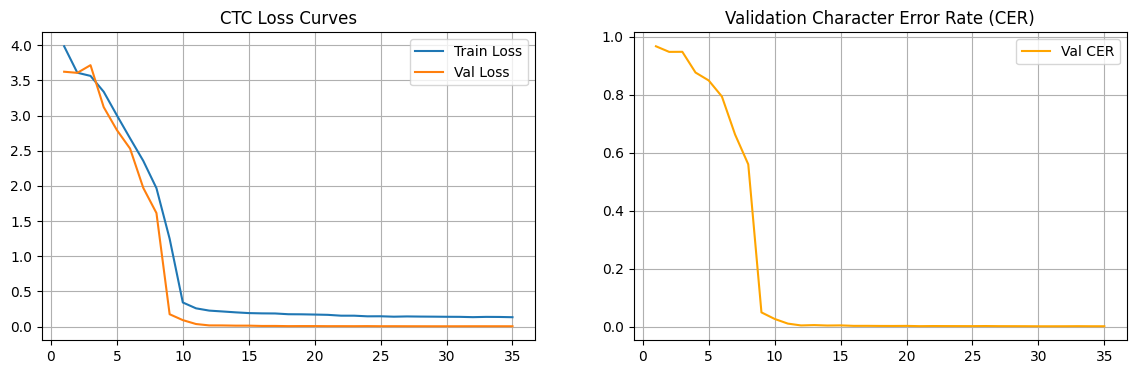

In [12]:
import os
ep_range = range(1, len(log['tl']) + 1)
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

ax[0].plot(ep_range, log['tl'], label='Train Loss')
ax[0].plot(ep_range, log['vl'], label='Val Loss')
ax[0].set_title('CTC Loss Curves')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(ep_range, log['bst_cer'], label='Val CER', color='orange')
ax[1].set_title('Validation Character Error Rate (CER)')
ax[1].legend()
ax[1].grid(True)

plt.show()

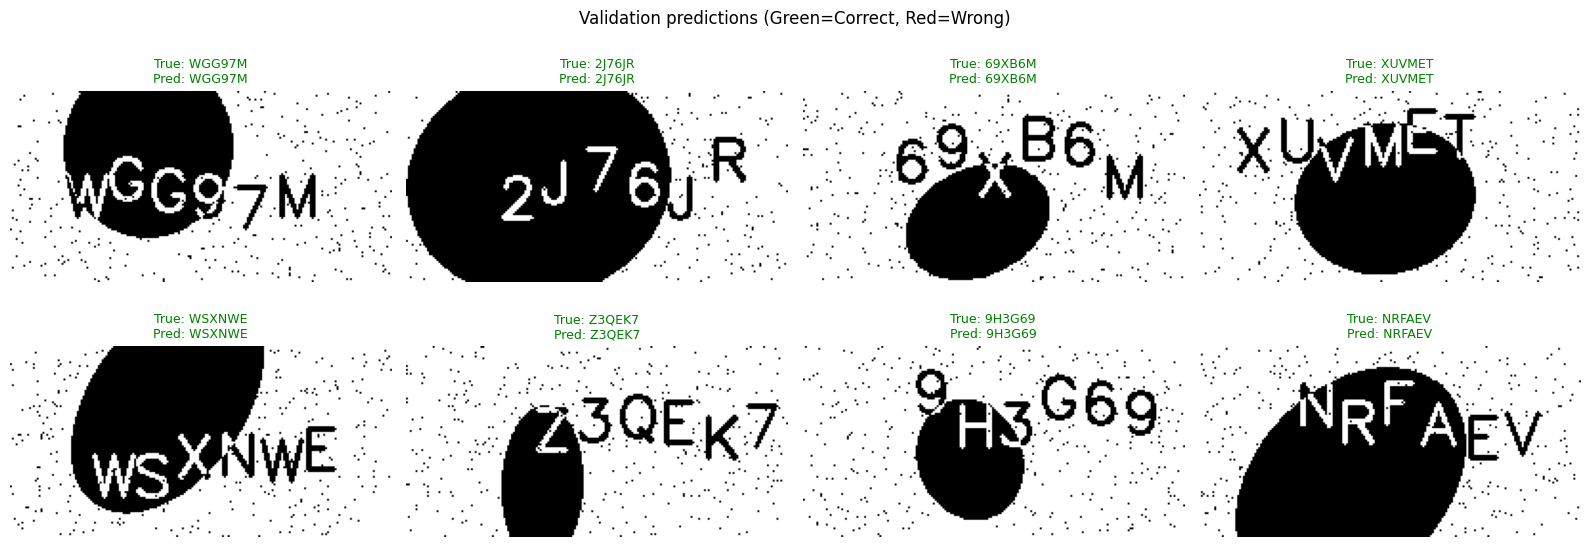

In [13]:
# Predictions on a handful of validation images.
# These are real decoder outputs, not the ground truth echoed back.
net.eval()
demo_df = vdf.sample(8, random_state=42).reset_index(drop=True)
demo_ds = ImgDS(demo_df, tr_dir, c2i, transform=vaug)
demo_dl = DataLoader(demo_ds, batch_size=8, shuffle=False, collate_fn=collate_fn)

imgs, _, _, gts = next(iter(demo_dl))
with torch.no_grad():
    preds = greedy(net(imgs.to(dev)), i2c, blank_idx=0)

fig, axes = plt.subplots(2, 4, figsize=(16, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(cv2.imread(str(tr_dir / demo_df.loc[i, 'image']), cv2.IMREAD_GRAYSCALE),
              cmap='gray')
    ok = preds[i] == gts[i]
    ax.set_title(f'True: {gts[i]}\nPred: {preds[i]}',
                 color='green' if ok else 'red', fontsize=9)
    ax.axis('off')
plt.suptitle('Validation predictions (Green=Correct, Red=Wrong)')
plt.tight_layout()
plt.show()


## Error Analysis
Analyse which characters the model confuses most, visualise per-character error rates,
and generate a confusion matrix heatmap.

In [14]:
from collections import defaultdict

#  Gather all val predictions ─
ckpt = torch.load(savepath, map_location=dev)
net.load_state_dict(ckpt['wts'])
net.eval()

all_p, all_g = [], []
with torch.no_grad():
    for imgs, tgt, lens, texts in tqdm(vdl, desc='Eval'):
        imgs = imgs.to(dev)
        lp = net(imgs)
        preds = greedy(lp, i2c, blank_idx=0)
        all_p.extend(preds)
        all_g.extend(texts)

vc  = cer_fn(all_p, all_g)
wacc = sum(p == g for p, g in zip(all_p, all_g)) / len(all_g)

print(f'Val CER          : {vc:.4f} ({vc*100:.2f}%)')
print(f'Word Accuracy    : {wacc:.4f} ({wacc*100:.2f}%)')
print(f'Wrong predictions: {sum(p!=g for p,g in zip(all_p, all_g))} / {len(all_g)}')

Eval:   0%|          | 0/32 [00:00<?, ?it/s]

Val CER          : 0.0009 (0.09%)
Word Accuracy    : 0.9945 (99.45%)
Wrong predictions: 11 / 2000


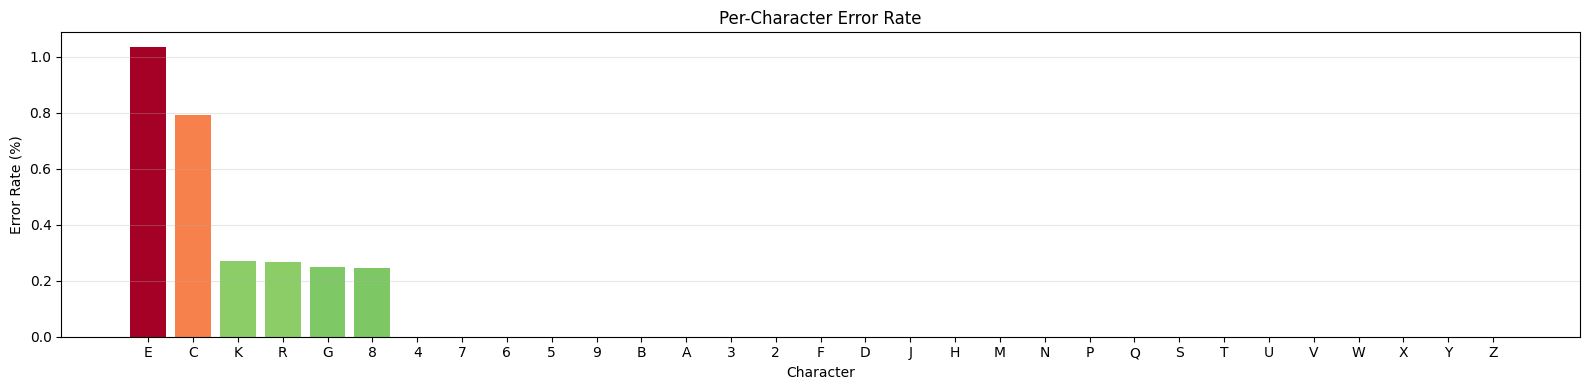


Top-10 hardest characters:
Char  Error Rate  Errors  Total
   E    0.010363       4    386
   C    0.007937       3    378
   K    0.002703       1    370
   R    0.002681       1    373
   G    0.002481       1    403
   8    0.002463       1    406
   4    0.000000       0    412
   7    0.000000       0    421
   6    0.000000       0    396
   5    0.000000       0    369


In [15]:
#  Per-Character Error Analysis
cerr = defaultdict(int)
ccnt = defaultdict(int)

for gt, pred in zip(all_g, all_p):
    for g_ch in gt:
        ccnt[g_ch] += 1
    for g_ch, p_ch in zip(gt, pred):
        if g_ch != p_ch:
            cerr[g_ch] += 1

crate = {c: cerr[c] / ccnt[c] for c in ccnt if ccnt[c] > 0}
cdf = pd.DataFrame([
    {'Char': c, 'Error Rate': crate[c], 'Errors': cerr[c], 'Total': ccnt[c]}
    for c in sorted(crate.keys())
]).sort_values('Error Rate', ascending=False)

fig, ax = plt.subplots(figsize=(16, 4))
palette = plt.cm.RdYlGn_r(np.array(cdf['Error Rate']) / max(cdf['Error Rate'].max(), 1e-9))
ax.bar(cdf['Char'], cdf['Error Rate'] * 100, color=palette)
ax.set_xlabel('Character')
ax.set_ylabel('Error Rate (%)')
ax.set_title('Per-Character Error Rate' )
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print('\nTop-10 hardest characters:')
print(cdf.head(10).to_string(index=False))

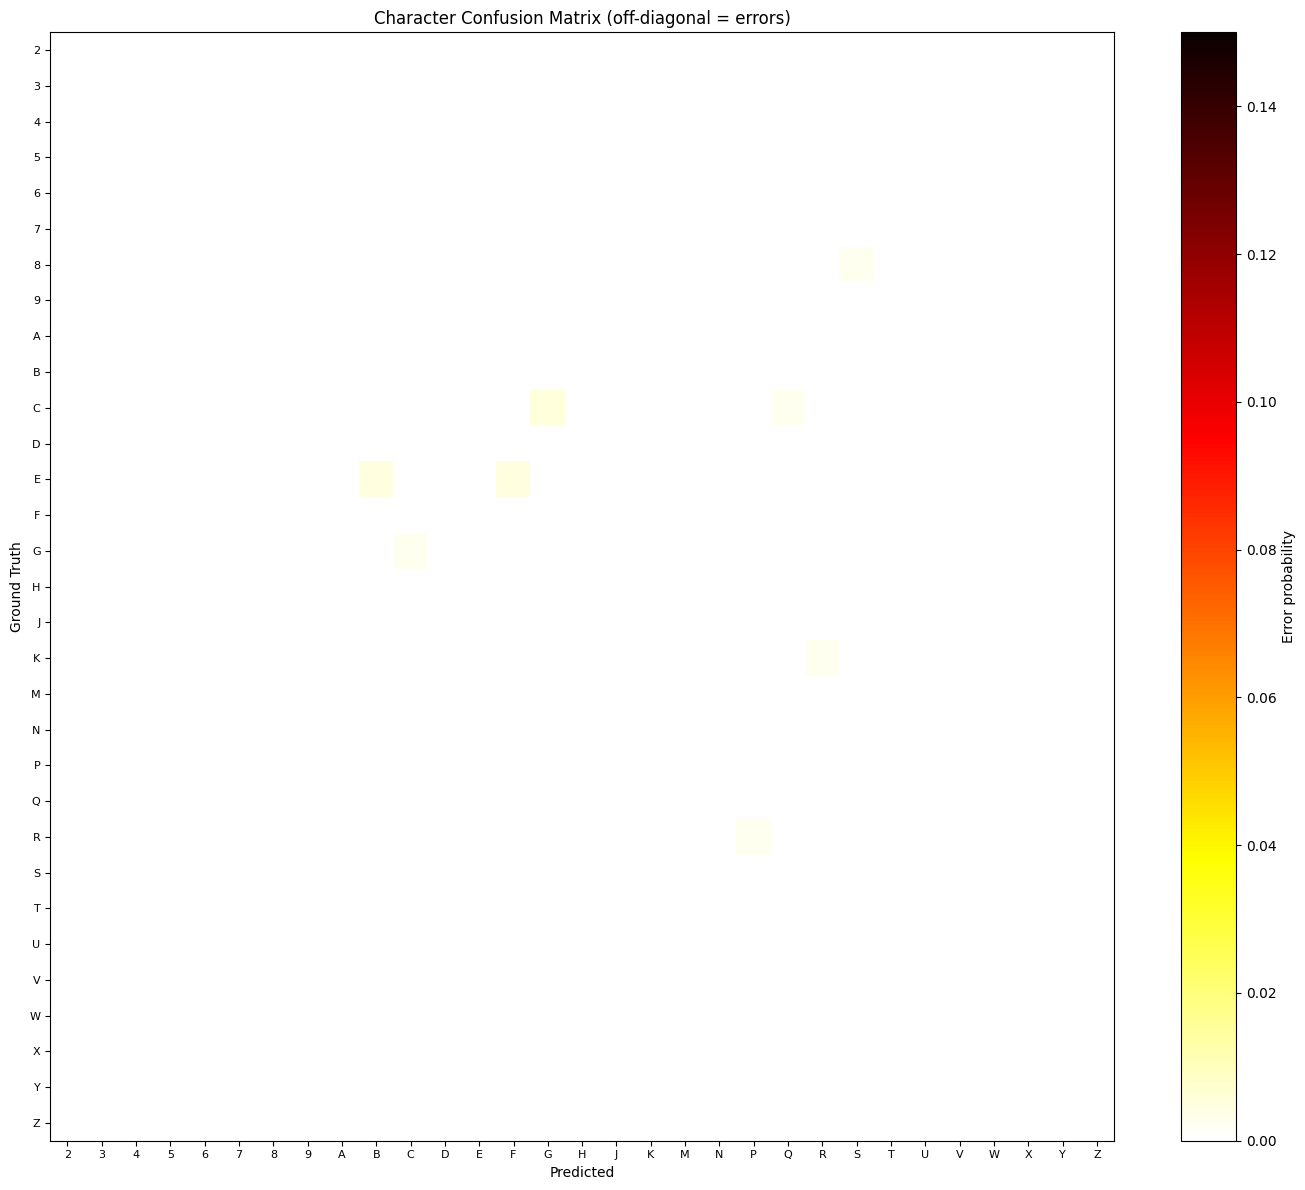


Top-10 character confusion pairs:
GT Pred  Count
 C    G      2
 E    B      2
 E    F      2
 8    S      1
 C    Q      1
 G    C      1
 K    R      1
 R    P      1


In [16]:
#  Character Confusion Matrix
rch = sorted(list(set(''.join(all_g))))
cm_idx = {c: i for i, c in enumerate(rch)}
n = len(rch)
cm = np.zeros((n, n), dtype=int)

for gt, pred in zip(all_g, all_p):
    for g, p in zip(gt, pred):
        if g in cm_idx and p in cm_idx:
            cm[cm_idx[g], cm_idx[p]] += 1

rs = cm.sum(axis=1, keepdims=True)
cm_n = np.where(rs > 0, cm / rs, 0.0)
cm_e = np.where(np.eye(n, dtype=bool), np.nan, cm_n)

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm_e, cmap='hot_r', aspect='auto', vmin=0, vmax=0.15)
plt.colorbar(im, ax=ax, label='Error probability')
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(rch, fontsize=8)
ax.set_yticklabels(rch, fontsize=8)
ax.set_xlabel('Predicted')
ax.set_ylabel('Ground Truth')
ax.set_title('Character Confusion Matrix (off-diagonal = errors)')

for i in range(n):
    for j in range(n):
        if i != j and cm_e[i,j] > 0.03:
            ax.text(j, i, f'{cm_e[i,j]:.2f}', ha='center', va='center',
                    fontsize=7, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

# Top confusion pairs
pairs = []
for i in range(n):
    for j in range(n):
        if i != j and cm[i,j] > 0:
            pairs.append({'GT': rch[i], 'Pred': rch[j], 'Count': cm[i,j]})
pairs = pd.DataFrame(pairs).sort_values('Count', ascending=False)
print('\nTop-10 character confusion pairs:')
print(pairs.head(10).to_string(index=False))

## 7. Final Submission CSV
Loading the best model weights and predicting on the test set

In [17]:
ckpt = torch.load(savepath, map_location=dev)
net.load_state_dict(ckpt['wts'])
net.eval()
print(f"Loaded best net from epoch {ckpt['ep']} (Best CER: {ckpt['bst_cer']:.4f})")

te_ds = TestDS(te_dir, transform=vaug)
tdl = DataLoader(te_ds, batch_size=64, shuffle=False, num_workers=nw, pin_memory=pin, persistent_workers=False)
print(f"Loaded {len(te_ds)} test images.")

rows = []
with torch.no_grad():
    for imgs, filenames in tqdm(tdl, desc="Inference"):
        imgs = imgs.to(dev)
        lp = net(imgs)
        decoded = greedy(lp, i2c, blank_idx=0)
        for fname, text in zip(filenames, decoded):
            rows.append({'image': fname, 'prediction': text})

sub = pd.DataFrame(rows)

# quick check
assert len(sub) == len(te_ds), f"Expected {len(te_ds)} rows, got {len(sub)}"
assert list(sub.columns) == ['image', 'prediction'], "Incorrect columns!"
assert sub['image'].is_unique, "duplicate filenames in submission"
if len(sub) != 5000:
    print(f"NOTE: test set has {len(sub)} images, not the 5000 originally assumed.")
if (sub['prediction'].str.len() == 0).any():
    print(f"WARNING: {(sub['prediction'].str.len() == 0).sum()} empty predictions "
          "- the decoder emitted only blanks for these.")

# write file
out_f = root / 'submission_AryanMehra_23115025.csv'
sub.to_csv(out_f, index=False)
print(f"output exported to: {out_f}")

Loaded best net from epoch 30 (Best CER: 0.0009)
Loaded 5000 test images.


Inference:   0%|          | 0/79 [00:00<?, ?it/s]

output exported to: /content/drive/MyDrive/CIG_Pattern_Recognition/submission_AryanMehra_23115025.csv


In [18]:

sub.head(10)

,image,prediction
0,test-0.png,QVTQ8A
1,test-1.png,7PSW9D
2,test-2.png,WJ2WNY
3,test-3.png,RFHJD4
4,test-4.png,K7ZUF2
5,test-5.png,CPMUBK
6,test-6.png,UZDRAW
7,test-7.png,2YDPJR
8,test-8.png,H5SG63
9,test-9.png,B2Z823


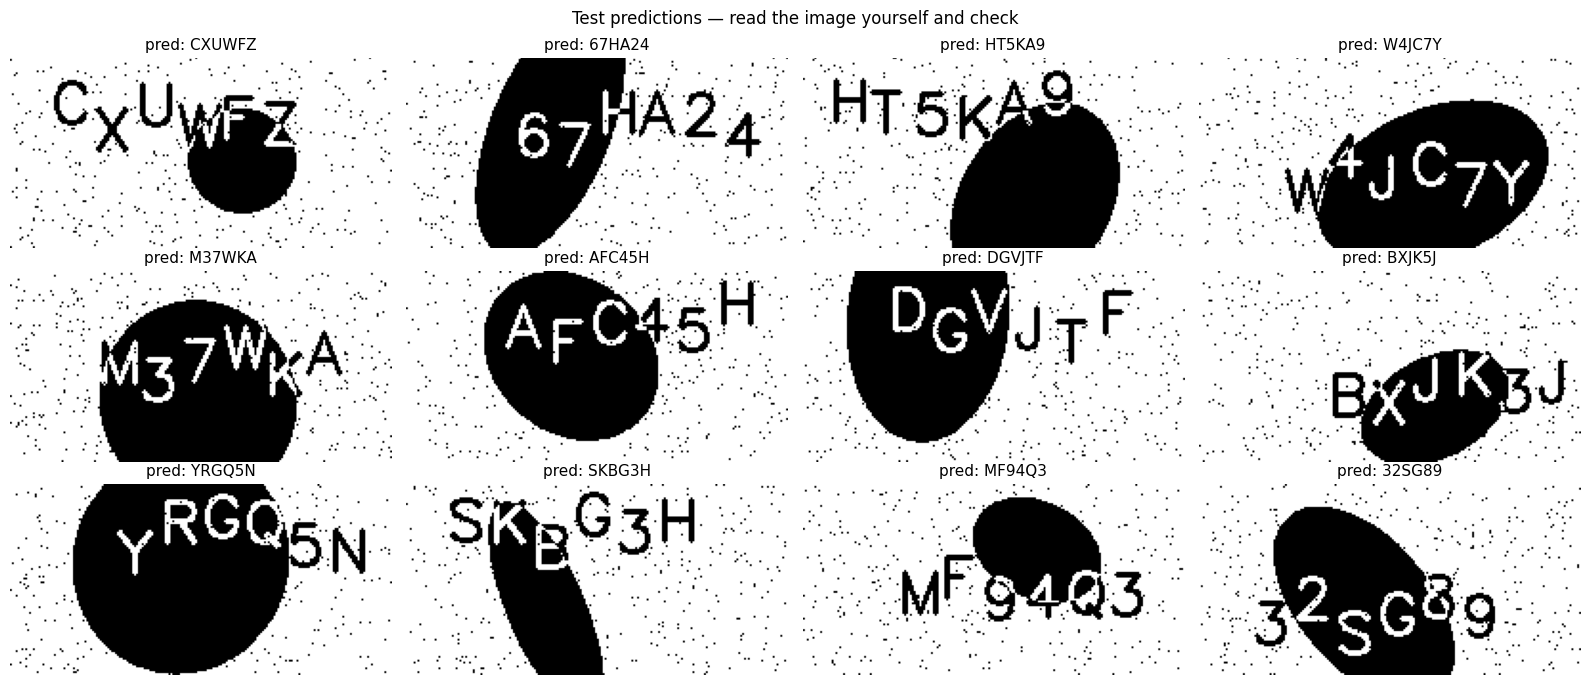

In [19]:
import matplotlib.pyplot as plt

n = 12
picks = sub.sample(n, random_state=0).reset_index(drop=True)

fig, axes = plt.subplots(3, 4, figsize=(16, 7))
for i, ax in enumerate(axes.flat):
    fn = picks.loc[i, 'image']
    ax.imshow(cv2.imread(str(te_dir / fn), cv2.IMREAD_GRAYSCALE), cmap='gray')
    ax.set_title(f"pred: {picks.loc[i, 'prediction']}", fontsize=11)
    ax.axis('off')
plt.suptitle('Test predictions — read the image yourself and check')
plt.tight_layout()
plt.show()